   ID_Cliente  Edad Sexo  Monto_Compras  Visitas  Devoluciones  Reseñas
0           1  25.0    M          100.0        5             0        4
1           2  30.0    F          200.0        3             1        5
2           3   NaN    M           50.0        2             0        3
3           4  40.0    F            NaN        4             1        4
4           5  35.0    M          150.0        1             0        5
Variables cuantitativas: ['Edad', 'Monto_Compras', 'Visitas', 'Devoluciones', 'Reseñas']
Variables categóricas: ['Sexo']
Valores faltantes: ID_Cliente       0
Edad             1
Sexo             0
Monto_Compras    1
Visitas          0
Devoluciones     0
Reseñas          0
dtype: int64
Valores faltantes después de reemplazar: ID_Cliente       0
Edad             0
Sexo             0
Monto_Compras    0
Visitas          0
Devoluciones     0
Reseñas          0
dtype: int64
       ID_Cliente      Edad  Monto_Compras   Visitas  Devoluciones  Reseñas
count    5.000000  

/tmp/ipython-input-908863893.py:37: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Edad'].fillna(df['Edad'].mean(), inplace=True)
/tmp/ipython-input-908863893.py:38: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

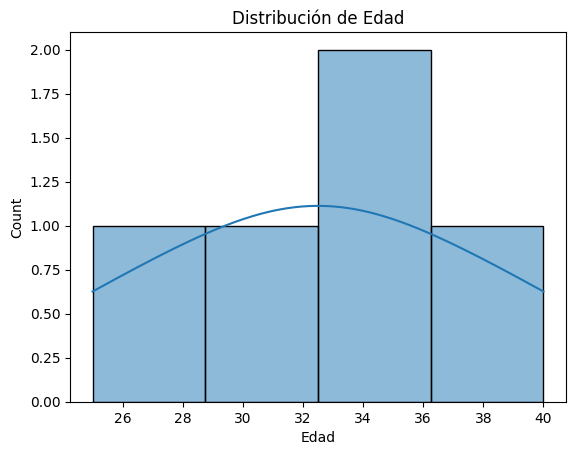

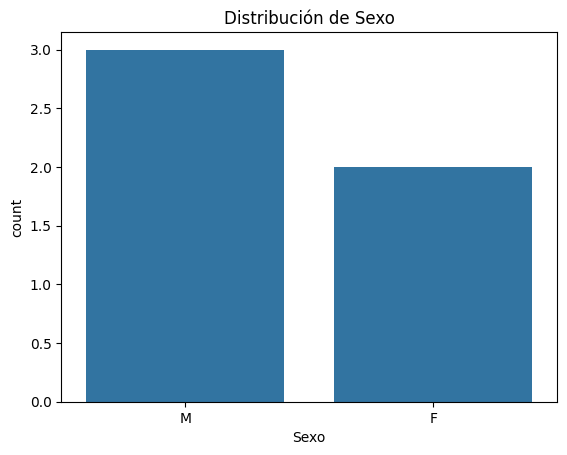

In [3]:
#Lección 1: Análisis Exploratorio

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# generar set datos
data = {
    'ID_Cliente': [1, 2, 3, 4, 5],
    'Edad': [25, 30, np.nan, 40, 35],
    'Sexo': ['M', 'F', 'M', 'F', 'M'],
    'Monto_Compras': [100, 200, 50, np.nan, 150],
    'Visitas': [5, 3, 2, 4, 1],
    'Devoluciones': [0, 1, 0, 1, 0],
    'Reseñas': [4, 5, 3, 4, 5]
}

df = pd.DataFrame(data)
print(df)


#Distinguir variables cuantitativas y categóricas
# Variables cuantitativas
cuantitativas = ['Edad', 'Monto_Compras', 'Visitas', 'Devoluciones', 'Reseñas']
print("Variables cuantitativas:", cuantitativas)

# Variables categóricas
categoricas = ['Sexo']
print("Variables categóricas:", categoricas)

#Detectar valores faltantes o inconsistencias:
# Detectar valores faltantes
print("Valores faltantes:", df.isnull().sum())

#reemplazar valores faltantes con la media
df['Edad'].fillna(df['Edad'].mean(), inplace=True)
df['Monto_Compras'].fillna(df['Monto_Compras'].mean(), inplace=True)

#verificar valores faltantes
print("Valores faltantes después de reemplazar:", df.isnull().sum())

#primeros hallazgos
# Resumen estadístico
print(df.describe())

#histograma edad
sns.histplot(df['Edad'], kde=True)
plt.title('Distribución de Edad')
plt.show()

#barras por sexo
sns.countplot(x='Sexo', data=df)
plt.title('Distribución de Sexo')
plt.show()



Media de Edad: 31.5
Mediana de Edad: 30.0
Moda de Edad: 25.0
Varianza de Edad: 36.25
Desviación estándar de Edad: 6.020797289396148
Cuartiles de Edad: 0.25    27.5
0.50    30.0
0.75    35.0
Name: Edad, dtype: float64
Percentiles de Edad: 0.1    26.0
0.5    30.0
0.9    38.0
Name: Edad, dtype: float64


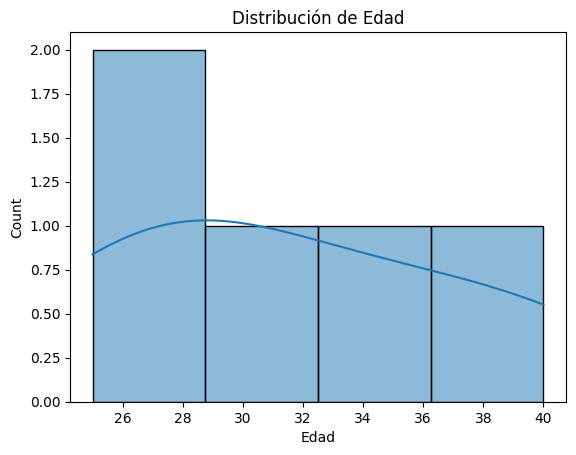

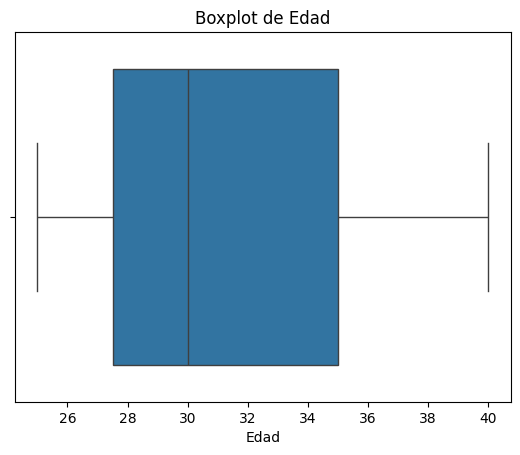

Valores atípicos de Edad: Series([], Name: Edad, dtype: float64)


In [5]:
#Lección 2: Estadística Descriptiva

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#dataset de la Lección 1
data = {
    'ID_Cliente': [1, 2, 3, 4, 5],
    'Edad': [25, 30, 27.5, 40, 35],
    'Sexo': ['M', 'F', 'M', 'F', 'M'],
    'Monto_Compras': [100, 200, 50, 137.5, 150],
    'Visitas': [5, 3, 2, 4, 1],
    'Devoluciones': [0, 1, 0, 1, 0],
    'Reseñas': [4, 5, 3, 4, 5]
}

df = pd.DataFrame(data)

#medidas estadísticas para "Edad"
# Media
media = df['Edad'].mean()
print("Media de Edad:", media)

# Mediana
mediana = df['Edad'].median()
print("Mediana de Edad:", mediana)

# Moda
moda = df['Edad'].mode()[0]
print("Moda de Edad:", moda)

# Varianza
varianza = df['Edad'].var()
print("Varianza de Edad:", varianza)

# Desviación estándar
desviacion_estandar = df['Edad'].std()
print("Desviación estándar de Edad:", desviacion_estandar)

#cuartiles
cuartiles = df['Edad'].quantile([0.25, 0.5, 0.75])
print("Cuartiles de Edad:", cuartiles)

#percentiles
percentiles = df['Edad'].quantile([0.1, 0.5, 0.9])
print("Percentiles de Edad:", percentiles)

#histograma
sns.histplot(df['Edad'], kde=True)
plt.title('Distribución de Edad')
plt.show()

#boxplot
sns.boxplot(x=df['Edad'])
plt.title('Boxplot de Edad')
plt.show()

#IQR, valores atípicos
Q1 = df['Edad'].quantile(0.25)
Q3 = df['Edad'].quantile(0.75)
IQR = Q3 - Q1
valores_atipicos = df[(df['Edad'] < (Q1 - 1.5 * IQR)) | (df['Edad'] > (Q3 + 1.5 * IQR))]['Edad']
print("Valores atípicos de Edad:", valores_atipicos)



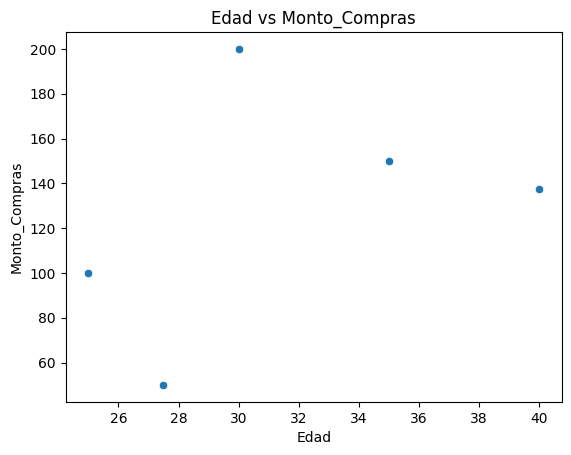

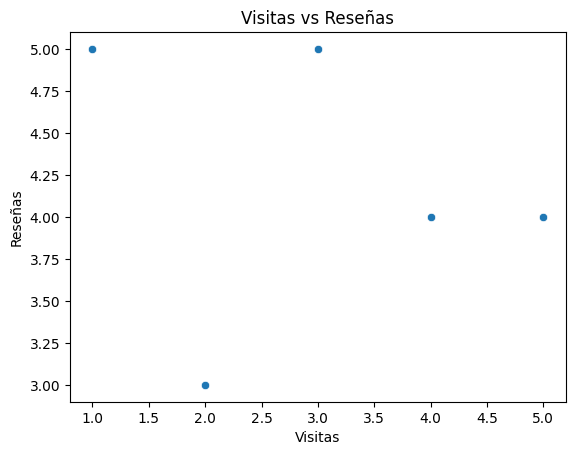

                   Edad  Monto_Compras   Visitas   Reseñas
Edad           1.000000       0.401883 -0.196960  0.297775
Monto_Compras  0.401883       1.000000 -0.035180  0.917475
Visitas       -0.196960      -0.035180  1.000000 -0.188982
Reseñas        0.297775       0.917475 -0.188982  1.000000


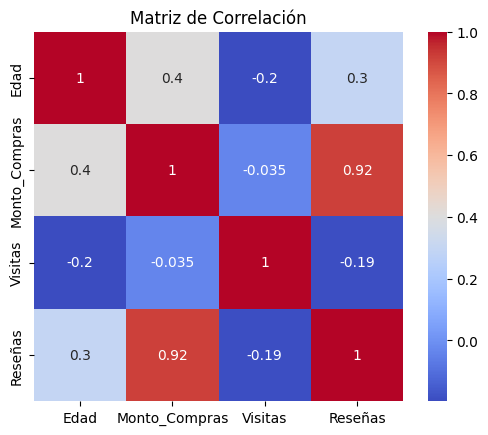

Coeficiente de Pearson (R) entre Edad y Monto_Compras: 0.4018829443881626
Coeficiente de Pearson (R) entre Visitas y Reseñas: -0.18898223650461363
La correlación entre Edad y Monto_Compras puede ser espuria debido a la pequeña muestra
La correlación entre Visitas y Reseñas podría ser significativa
La matriz de correlación muestra una correlación positiva entre Edad y Monto_Compras
El scatterplot de Edad vs Monto_Compras muestra una tendencia positiva
La matriz de correlación muestra una correlación negativa entre Visitas y Reseñas
El scatterplot de Visitas vs Reseñas muestra una tendencia negativa


In [8]:
#Lección 3: Correlación de Datos

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# dataset de Lección 1
data = {
    'ID_Cliente': [1, 2, 3, 4, 5],
    'Edad': [25, 30, 27.5, 40, 35],
    'Sexo': ['M', 'F', 'M', 'F', 'M'],
    'Monto_Compras': [100, 200, 50, 137.5, 150],
    'Visitas': [5, 3, 2, 4, 1],
    'Devoluciones': [0, 1, 0, 1, 0],
    'Reseñas': [4, 5, 3, 4, 5]
}

df = pd.DataFrame(data)

# Scatterplot de Edad vs Monto_Compras
sns.scatterplot(x='Edad', y='Monto_Compras', data=df)
plt.title('Edad vs Monto_Compras')
plt.show()

# Scatterplot de Visitas vs Reseñas
sns.scatterplot(x='Visitas', y='Reseñas', data=df)
plt.title('Visitas vs Reseñas')
plt.show()

# Matriz de correlación
corr_matrix = df[['Edad', 'Monto_Compras', 'Visitas', 'Reseñas']].corr()
print(corr_matrix)

# Mapa de calor de la matriz de correlación
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', square=True)
plt.title('Matriz de Correlación')
plt.show()

# Coeficiente de Pearson (R) entre Edad y Monto_Compras
r, p = np.corrcoef(df['Edad'], df['Monto_Compras'])[0, 1], 0
print("Coeficiente de Pearson (R) entre Edad y Monto_Compras:", r)

# Coeficiente de Pearson (R) entre Visitas y Reseñas
r, p = np.corrcoef(df['Visitas'], df['Reseñas'])[0, 1], 0
print("Coeficiente de Pearson (R) entre Visitas y Reseñas:", r)

print("La correlación entre Edad y Monto_Compras puede ser espuria debido a la pequeña muestra")
print("La correlación entre Visitas y Reseñas podría ser significativa")
print("La matriz de correlación muestra una correlación positiva entre Edad y Monto_Compras")
print("El scatterplot de Edad vs Monto_Compras muestra una tendencia positiva")
print("La matriz de correlación muestra una correlación negativa entre Visitas y Reseñas")
print("El scatterplot de Visitas vs Reseñas muestra una tendencia negativa")



/usr/local/lib/python3.12/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


                            OLS Regression Results                            
Dep. Variable:          Monto_Compras   R-squared:                       0.162
Model:                            OLS   Adj. R-squared:                 -0.118
Method:                 Least Squares   F-statistic:                    0.5779
Date:                Mon, 23 Feb 2026   Prob (F-statistic):              0.502
Time:                        00:26:19   Log-Likelihood:                -26.239
No. Observations:                   5   AIC:                             56.48
Df Residuals:                       3   BIC:                             55.70
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.3750    157.647      0.059      0.9

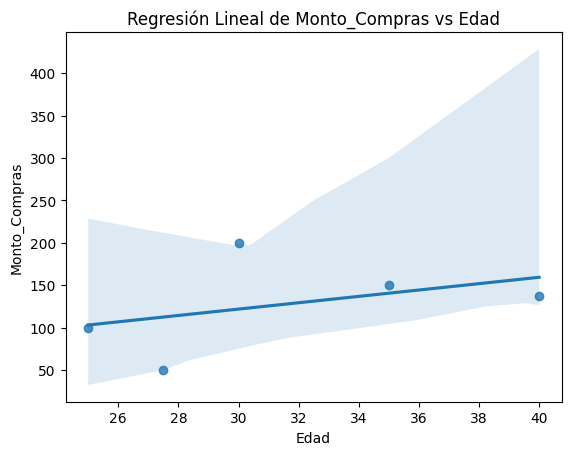

BAJÍSIMA BONDAD DE AJUSTE. EL PRINCIPAL PROBLEMA CORRESPONDE A QUE SON MUY POCOS DATOS
COMO PARA GENERAR LA NORMALIDAD NECESARIA QUE MEJORA EL AJUSTE. ESTE MODELO NO ES ÚTIL


In [12]:
#Lección 4: Regresión Lineal

#predecir el Monto_Compras en función de Edad

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_error

# dataset Lección 1
data = {
    'ID_Cliente': [1, 2, 3, 4, 5],
    'Edad': [25, 30, 27.5, 40, 35],
    'Sexo': ['M', 'F', 'M', 'F', 'M'],
    'Monto_Compras': [100, 200, 50, 137.5, 150],
    'Visitas': [5, 3, 2, 4, 1],
    'Devoluciones': [0, 1, 0, 1, 0],
    'Reseñas': [4, 5, 3, 4, 5]
}

df = pd.DataFrame(data)

# modelo de regresión lineal. variable dependiente (y) y la variable independiente (X)
y = df['Monto_Compras']
X = df[['Edad']]

# Agregar una constante a la variable independiente
X = sm.add_constant(X)

# Ajustar el modelo de regresión lineal por mínimos cuadrados
model = sm.OLS(y, X).fit()

# Imprimir el resumen del modelo
print(model.summary())

# Calcular R2
r2 = model.rsquared
print("R2:", r2)

# Calcular MSE
mse = mean_squared_error(y, model.predict(X))
print("MSE:", mse)

# Calcular MAE
mae = mean_absolute_error(y, model.predict(X))
print("MAE:", mae)

# La significancia del predictor Edad se puede evaluar con el p-value
p_value = model.pvalues['Edad']
print("p-value de Edad:", p_value)

# Si el p-value es menor que 0.05, el predictor es significativo
if p_value < 0.05:
    print("El predictor Edad es significativo")
else:
    print("El predictor Edad no es significativo")

# El coeficiente de Edad representa el cambio en Monto_Compras por unidad de cambio en Edad
coeficiente = model.params['Edad']
print("Coeficiente de Edad:", coeficiente)

# La constante representa el valor de Monto_Compras cuando Edad es 0
constante = model.params['const']
print("Constante:", constante)

# Visualizar la regresión con Seaborn
sns.regplot(x='Edad', y='Monto_Compras', data=df)
plt.title('Regresión Lineal de Monto_Compras vs Edad')
plt.show()

print("BAJÍSIMA BONDAD DE AJUSTE. EL PRINCIPAL PROBLEMA CORRESPONDE A QUE SON MUY POCOS DATOS")
print("COMO PARA GENERAR LA NORMALIDAD NECESARIA QUE MEJORA EL AJUSTE. ESTE MODELO NO ES ÚTIL")


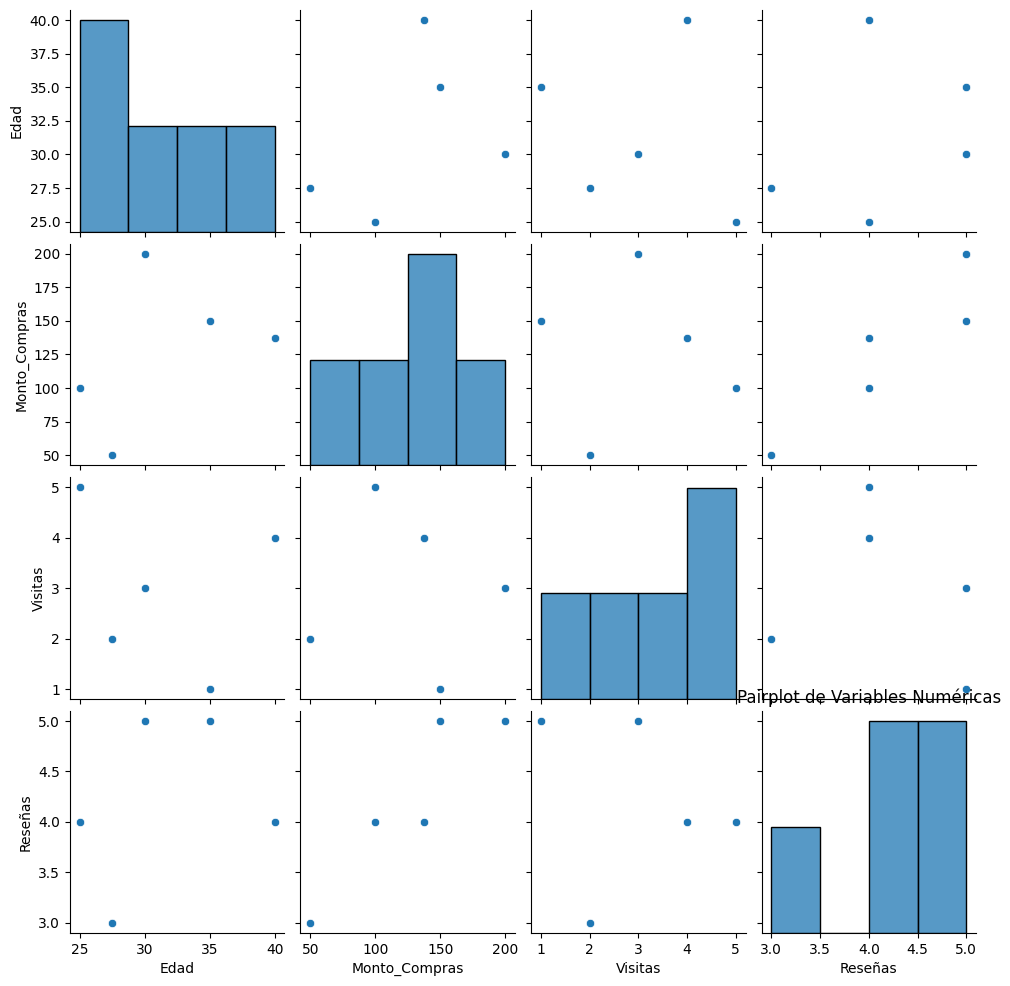

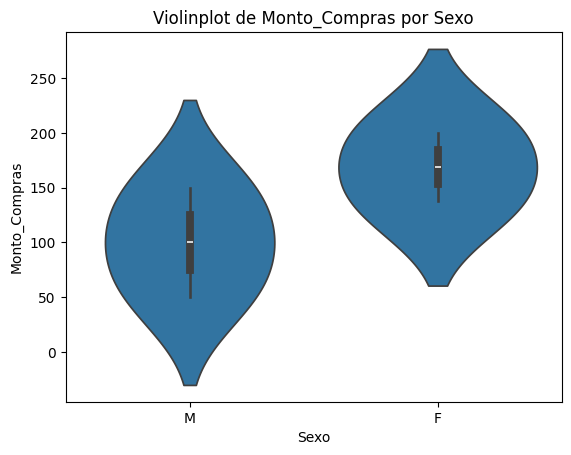

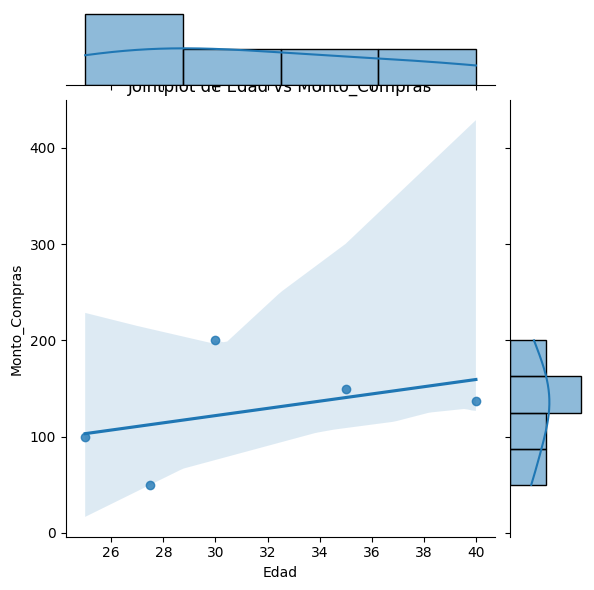

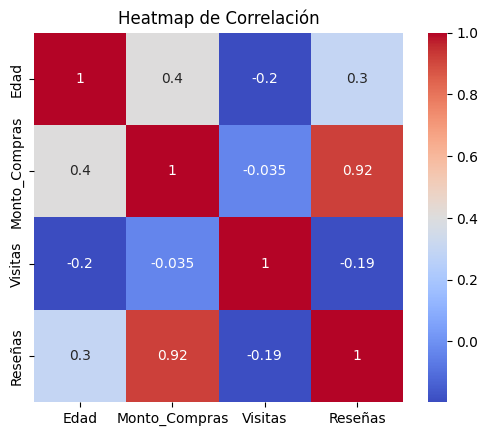

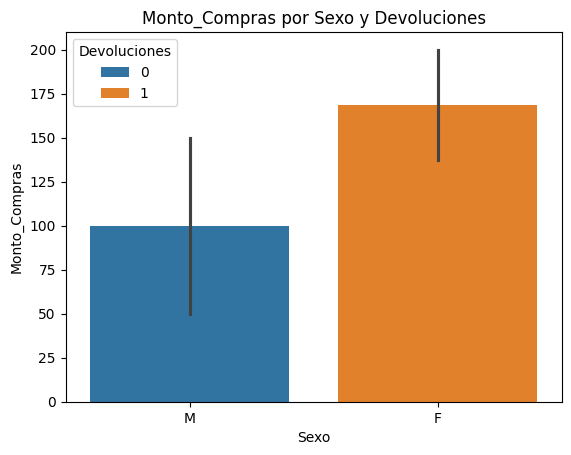

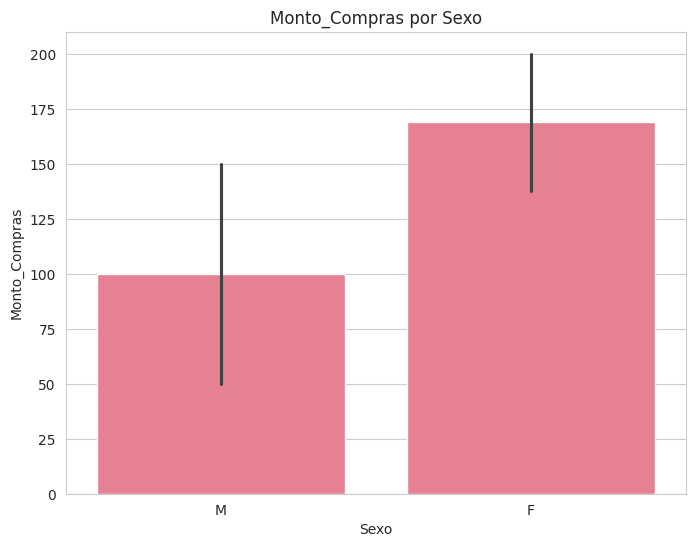

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:718: UserWarning: Using the barplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


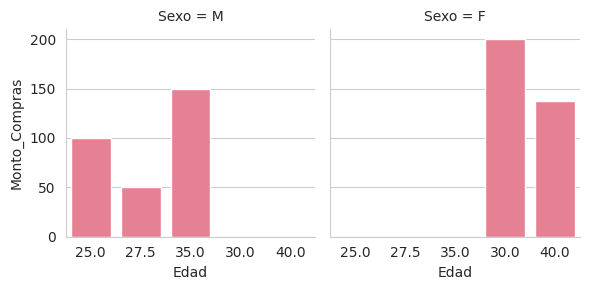

El pairplot muestra una relación positiva entre Edad y Monto_Compras
El violinplot muestra que los hombres tienen un Monto_Compras más alto que las mujeres
El jointplot muestra una relación positiva entre Edad y Monto_Compras
El heatmap muestra una correlación positiva entre Edad y Monto_Compras


In [13]:
#Lección 5: Análisis Visual

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# dataset Lección 1
data = {
    'ID_Cliente': [1, 2, 3, 4, 5],
    'Edad': [25, 30, 27.5, 40, 35],
    'Sexo': ['M', 'F', 'M', 'F', 'M'],
    'Monto_Compras': [100, 200, 50, 137.5, 150],
    'Visitas': [5, 3, 2, 4, 1],
    'Devoluciones': [0, 1, 0, 1, 0],
    'Reseñas': [4, 5, 3, 4, 5]
}

df = pd.DataFrame(data)


# Pairplot
sns.pairplot(df[['Edad', 'Monto_Compras', 'Visitas', 'Reseñas']])
plt.title('Pairplot de Variables Numéricas')
plt.show()

# Violinplot
sns.violinplot(x='Sexo', y='Monto_Compras', data=df)
plt.title('Violinplot de Monto_Compras por Sexo')
plt.show()

# Jointplot
sns.jointplot(x='Edad', y='Monto_Compras', data=df, kind='reg')
plt.title('Jointplot de Edad vs Monto_Compras')
plt.show()

# Heatmap
corr_matrix = df[['Edad', 'Monto_Compras', 'Visitas', 'Reseñas']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', square=True)
plt.title('Heatmap de Correlación')
plt.show()

# Gráfico de barras con múltiples variables
sns.barplot(x='Sexo', y='Monto_Compras', hue='Devoluciones', data=df)
plt.title('Monto_Compras por Sexo y Devoluciones')
plt.show()

# Ajustar estilo y colores
sns.set_style('whitegrid')
sns.set_palette('husl')

# Ajustar tamaño de la figura
plt.figure(figsize=(8, 6))

# Gráfico de barras con estilo y colores ajustados
sns.barplot(x='Sexo', y='Monto_Compras', data=df)
plt.title('Monto_Compras por Sexo')
plt.show()

# Crear un FacetGrid
g = sns.FacetGrid(df, col='Sexo')
g.map(sns.barplot, 'Edad', 'Monto_Compras')
plt.show()

print("El pairplot muestra una relación positiva entre Edad y Monto_Compras")
print("El violinplot muestra que los hombres tienen un Monto_Compras más alto que las mujeres")
print("El jointplot muestra una relación positiva entre Edad y Monto_Compras")
print("El heatmap muestra una correlación positiva entre Edad y Monto_Compras")


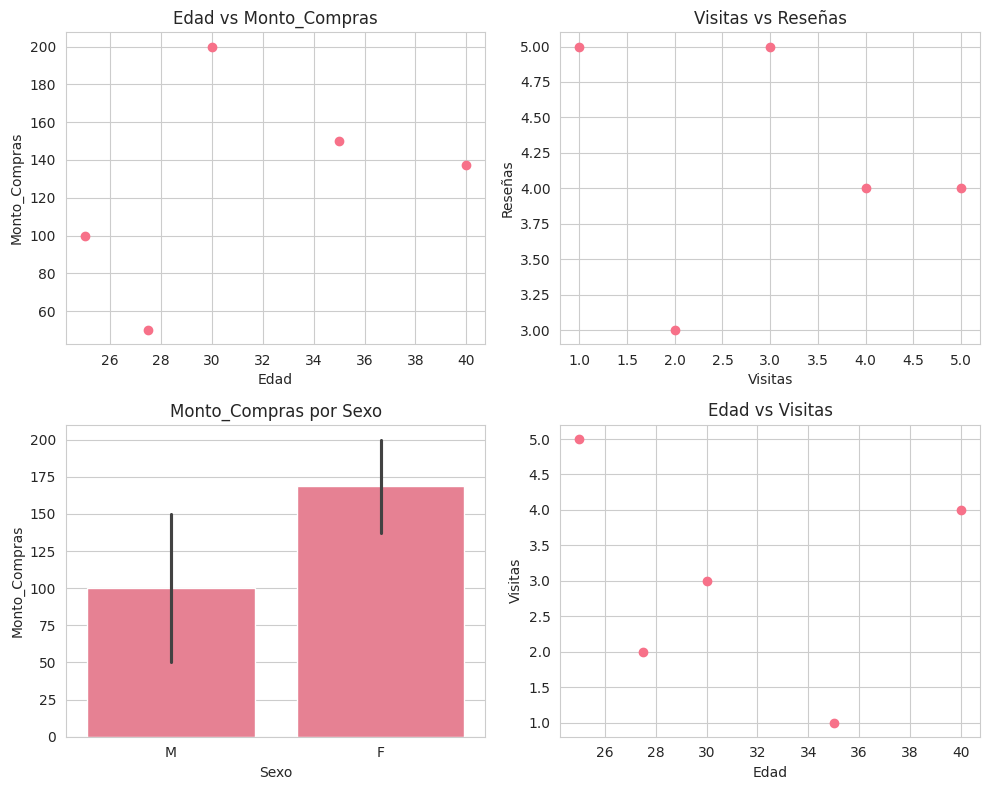

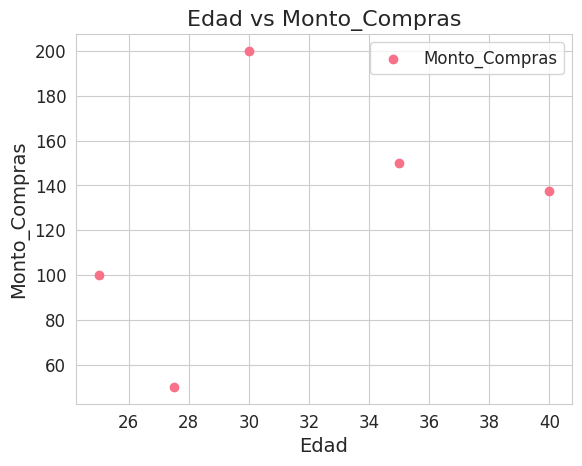

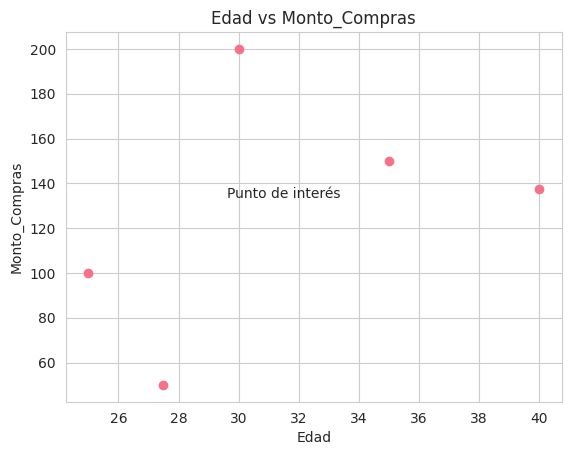

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Informe EDA
-----------
Estadísticas descriptivas
       ID_Cliente       Edad  Monto_Compras   Visitas  Devoluciones  Reseñas
count    5.000000   5.000000       5.000000  5.000000      5.000000  5.00000
mean     3.000000  31.500000     127.500000  3.000000      0.400000  4.20000
std      1.581139   6.020797      56.180513  1.581139      0.547723  0.83666
min      1.000000  25.000000      50.000000  1.000000      0.000000  3.00000
25%      2.000000  27.500000     100.000000  2.000000      0.000000  4.00000
50%      3.000000  30.000000     137.500000  3.000000      0.000000  4.00000
75%      4.000000  35.000000     150.000000  4.000000      1.000000  5.00000
max      5.000000  40.000000     200.000000  5.000000      1.000000  5.00000


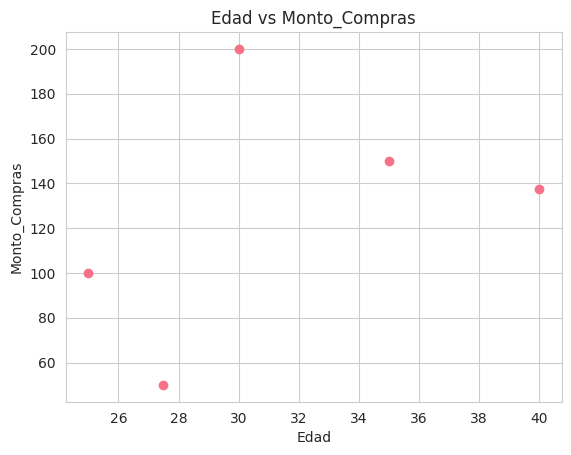

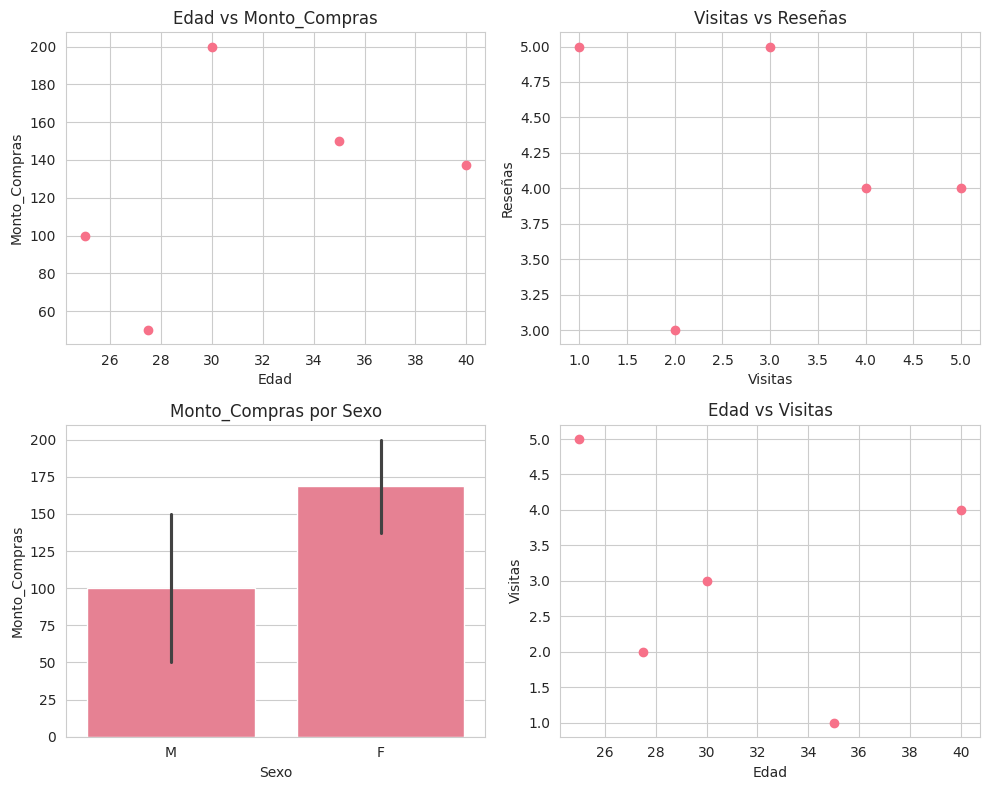

<Figure size 1000x800 with 0 Axes>

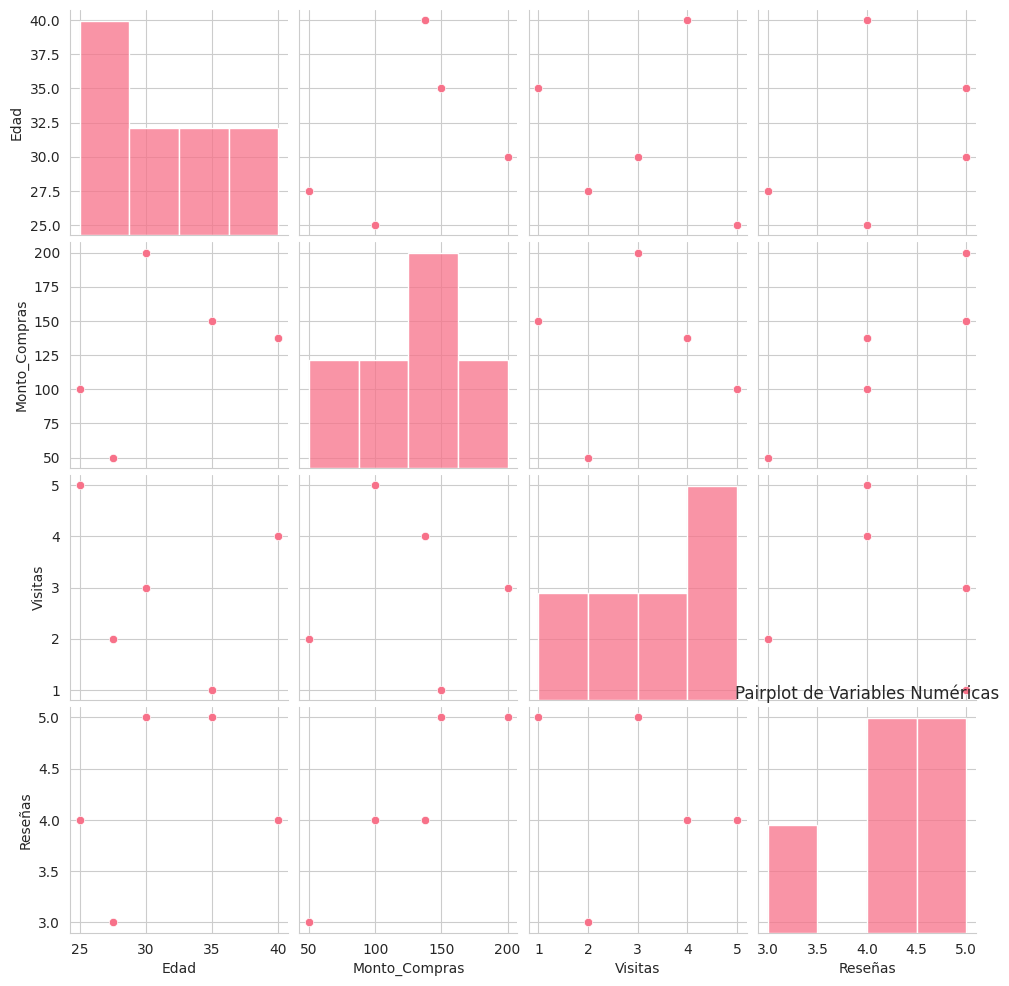

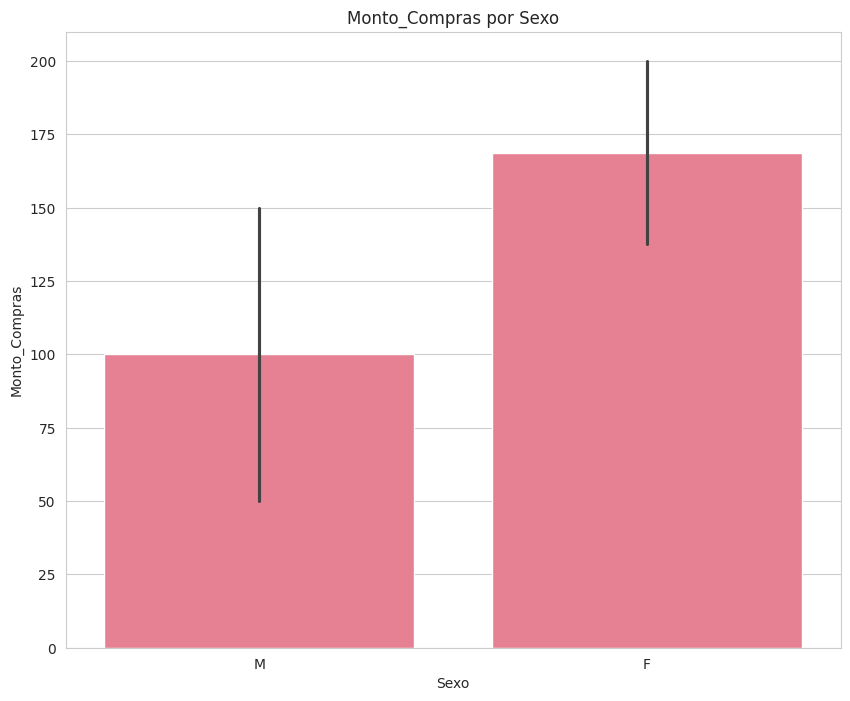

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
#Lección 6: Matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Creamos un dataset lección 1
data = {
    'ID_Cliente': [1, 2, 3, 4, 5],
    'Edad': [25, 30, 27.5, 40, 35],
    'Sexo': ['M', 'F', 'M', 'F', 'M'],
    'Monto_Compras': [100, 200, 50, 137.5, 150],
    'Visitas': [5, 3, 2, 4, 1],
    'Devoluciones': [0, 1, 0, 1, 0],
    'Reseñas': [4, 5, 3, 4, 5]
}

df = pd.DataFrame(data)

# Crear figura con subplots
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

# Gráfico 1: Edad vs Monto_Compras
axs[0, 0].scatter(df['Edad'], df['Monto_Compras'])
axs[0, 0].set_title('Edad vs Monto_Compras')
axs[0, 0].set_xlabel('Edad')
axs[0, 0].set_ylabel('Monto_Compras')

# Gráfico 2: Visitas vs Reseñas
axs[0, 1].scatter(df['Visitas'], df['Reseñas'])
axs[0, 1].set_title('Visitas vs Reseñas')
axs[0, 1].set_xlabel('Visitas')
axs[0, 1].set_ylabel('Reseñas')

# Gráfico 3: Monto_Compras por Sexo
sns.barplot(x='Sexo', y='Monto_Compras', data=df, ax=axs[1, 0])
axs[1, 0].set_title('Monto_Compras por Sexo')

# Gráfico 4: Edad vs Visitas
axs[1, 1].scatter(df['Edad'], df['Visitas'])
axs[1, 1].set_title('Edad vs Visitas')
axs[1, 1].set_xlabel('Edad')
axs[1, 1].set_ylabel('Visitas')

# Ajustar el layout
plt.tight_layout()

# Mostrar la figura
plt.show()

# Crear un gráfico con título y etiquetas personalizadas
plt.scatter(df['Edad'], df['Monto_Compras'])
plt.title('Edad vs Monto_Compras', fontsize=16)
plt.xlabel('Edad', fontsize=14)
plt.ylabel('Monto_Compras', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(['Monto_Compras'], fontsize=12)
plt.show()

# Crear un gráfico con anotación
plt.scatter(df['Edad'], df['Monto_Compras'])
plt.title('Edad vs Monto_Compras')
plt.xlabel('Edad')
plt.ylabel('Monto_Compras')
plt.annotate('Punto de interés', (df['Edad'].mean(), df['Monto_Compras'].mean()), textcoords='offset points', xytext=(0, 10), ha='center')
plt.show()

# Guardar el gráfico en un archivo
plt.scatter(df['Edad'], df['Monto_Compras'])
plt.title('Edad vs Monto_Compras')
plt.xlabel('Edad')
plt.ylabel('Monto_Compras')
plt.savefig('edad_vs_monto_compras.png', dpi=300, bbox_inches='tight')

# DESCARGAR ARCHIVO
from google.colab import files
files.download('edad_vs_monto_compras.png')

# Crear una presentación con gráficos
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

# Gráfico 1: Edad vs Monto_Compras
axs[0, 0].scatter(df['Edad'], df['Monto_Compras'])
axs[0, 0].set_title('Edad vs Monto_Compras')
axs[0, 0].set_xlabel('Edad')
axs[0, 0].set_ylabel('Monto_Compras')

# Gráfico 2: Visitas vs Reseñas
axs[0, 1].scatter(df['Visitas'], df['Reseñas'])
axs[0, 1].set_title('Visitas vs Reseñas')
axs[0, 1].set_xlabel('Visitas')
axs[0, 1].set_ylabel('Reseñas')

# Gráfico 3: Monto_Compras por Sexo
sns.barplot(x='Sexo', y='Monto_Compras', data=df, ax=axs[1, 0])
axs[1, 0].set_title('Monto_Compras por Sexo')

# Gráfico 4: Edad vs Visitas
axs[1, 1].scatter(df['Edad'], df['Visitas'])
axs[1, 1].set_title('Edad vs Visitas')
axs[1, 1].set_xlabel('Edad')
axs[1, 1].set_ylabel('Visitas')

# Ajustar el layout
plt.tight_layout()

# Guardar la presentación en un archivo
plt.savefig('presentacion_grafica.png', dpi=300, bbox_inches='tight')

# DESCARGAR ARCHIVO
from google.colab import files
files.download('presentacion_grafica.png')

# Crear un informe EDA con visualizaciones embebidas

print('Informe EDA')
print('-----------')

# Estadísticas descriptivas
print('Estadísticas descriptivas')
print(df.describe())

# Visualizaciones
plt.figure(figsize=(10, 8))
sns.pairplot(df[['Edad', 'Monto_Compras', 'Visitas', 'Reseñas']])
plt.title('Pairplot de Variables Numéricas')
plt.show()

plt.figure(figsize=(10, 8))
sns.barplot(x='Sexo', y='Monto_Compras', data=df)
plt.title('Monto_Compras por Sexo')
plt.show()

# Guardar el informe EDA en un archivo
with open('informe_eda.txt', 'w') as f:
    f.write('Informe EDA\n')
    f.write('-----------\n')
    f.write('Estadísticas descriptivas\n')
    f.write(str(df.describe()) + '\n')
    f.write('Visualizaciones\n')
    f.write('pairplot de variables numéricas\n')
    f.write('barplot de Monto_Compras por Sexo\n')

#DESCARGAR ARCHIVO
from google.colab import files
files.download('informe_eda.txt')


